# Credit Card Customer Churn Prediction using RANDOM FOREST ALGORITHM

The goal of this project is to predict which
credit card customers are likely to leave
the bank (churn).

By identifying at-risk customers early,
the bank can take action to retain them
before it's too late.

We used the BankChurners dataset which contains
information about 10,127 customers including
their age, income, spending behavior and
transaction history.

Machine Learning model Random Forest was used
to build a prediction system that achieved
95.4% accuracy and 0.98 AUC Score.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/BankChurners.csv")
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [2]:
df.shape

(10127, 23)

In [3]:
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

In [4]:
df.dtypes

,0
CLIENTNUM,int64
Attrition_Flag,object
Customer_Age,int64
Gender,object
Dependent_count,int64
Education_Level,object
Marital_Status,object
Income_Category,object
Card_Category,object
Months_on_book,int64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  object 
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                           

In [6]:
df.describe()

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990


 DATA CLEANING

In [7]:
df.isnull().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.drop([
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
], axis=1)

In [10]:
df.columns


Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')

The columns
`Naive_Bayes_Classifier_Attrition_Flag_..._1` and
`Naive_Bayes_Classifier_Attrition_Flag_..._2`
were removed from the dataset because they are not original input features. These columns represent the predicted probabilities generated by a Naive Bayes model.

Including these features in the dataset would lead to **data leakage**, as they already contain information derived from the target variable (`Attrition_Flag`). This would result in an unrealistically high model performance and compromise the validity of the analysis.

Therefore, to ensure a fair and unbiased model training process, these columns were excluded.


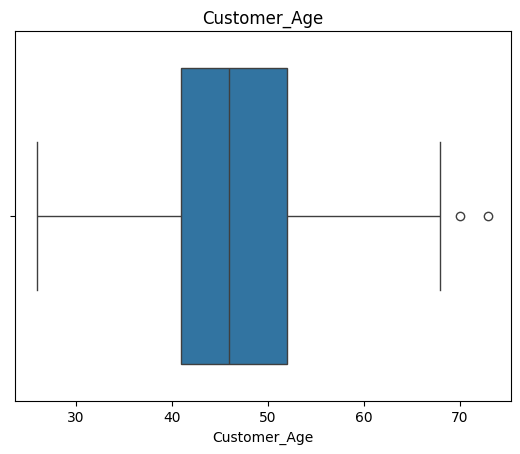

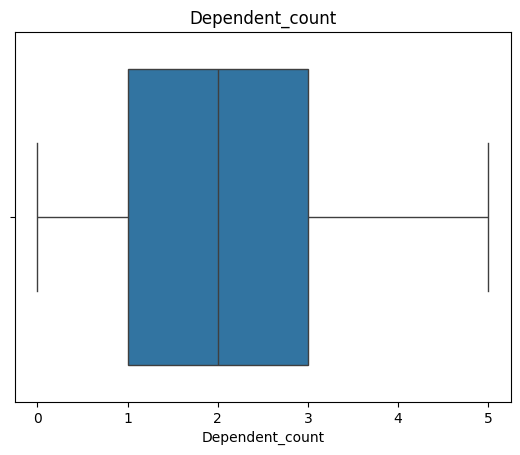

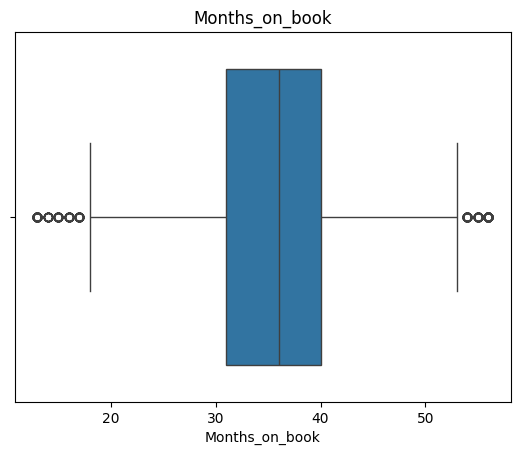

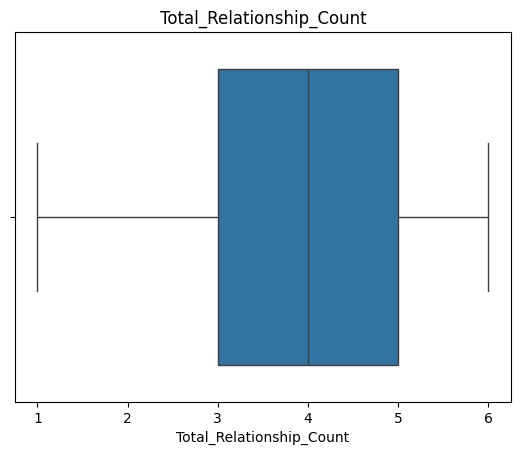

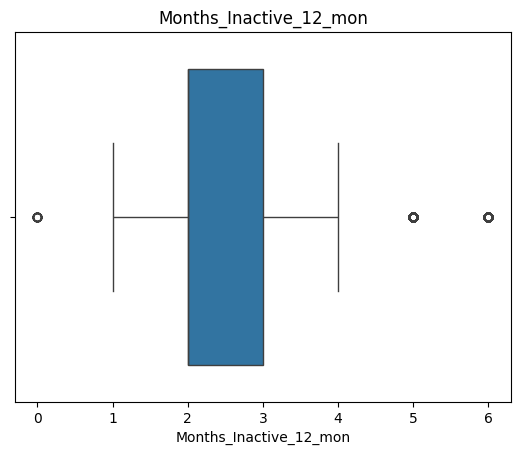

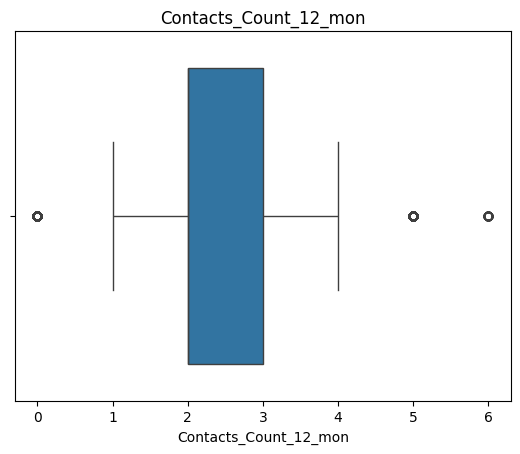

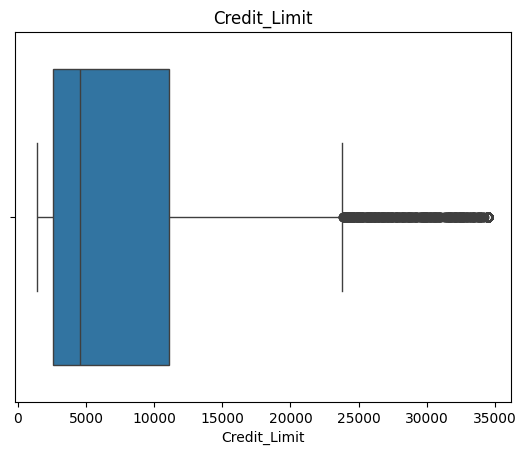

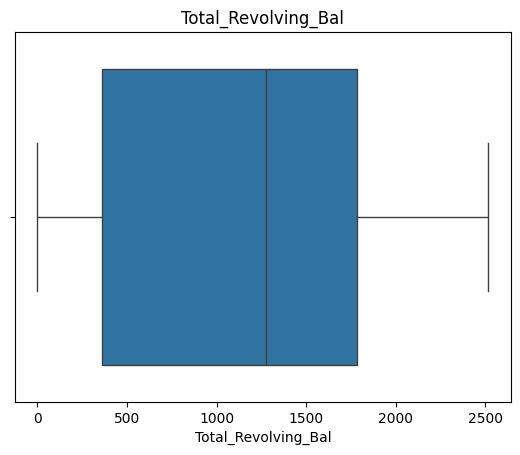

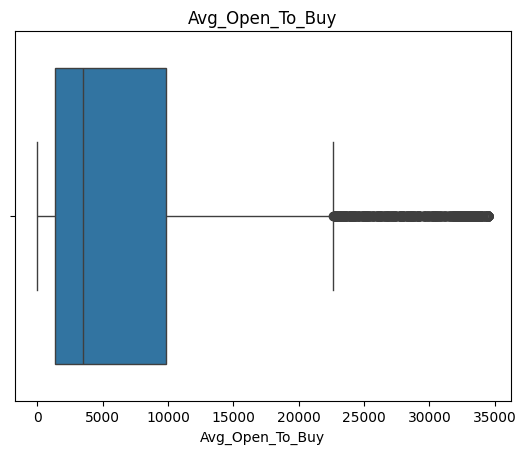

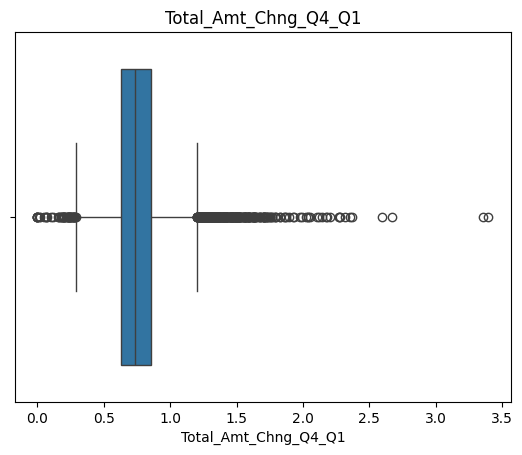

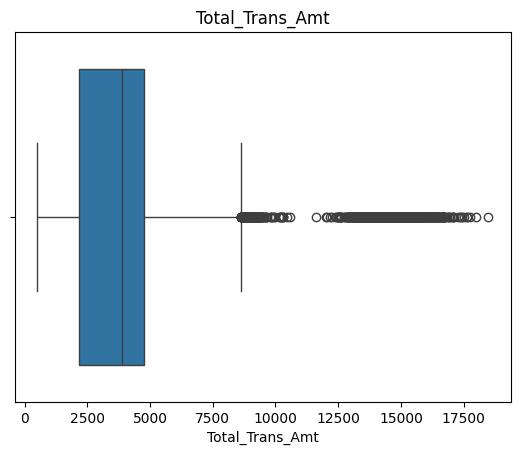

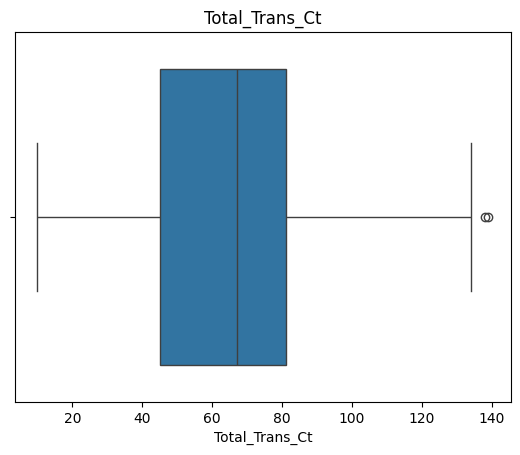

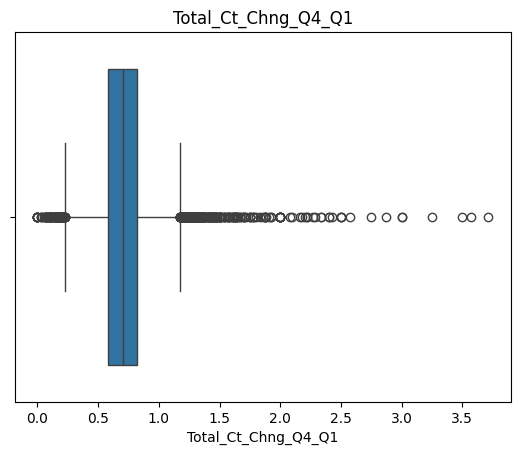

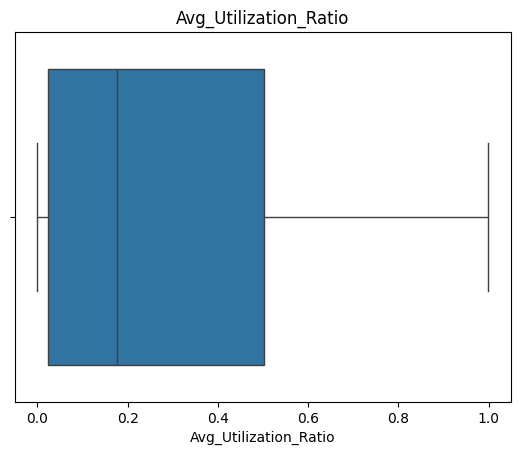

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Exclude 'CLIENTNUM' as it's an identifier
if 'CLIENTNUM' in numerical_cols:
    numerical_cols.remove('CLIENTNUM')
cols = numerical_cols

for col in cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [12]:
import numpy as np

df['Avg_Open_To_Buy'] = np.log1p(df['Avg_Open_To_Buy'])
df['Total_Trans_Amt'] = np.log1p(df['Total_Trans_Amt'])

In [13]:
cols = ['Total_Amt_Chng_Q4_Q1', 'Total_Ct_Chng_Q4_Q1']

for col in cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    df[col] = df[col].clip(lower, upper)

features with a high number of outliers were treated using appropriate techniques instead of removal. Highly skewed numerical features were transformed using log transformation, while ratio-based features were handled using the IQR capping method to preserve important patterns in the data.

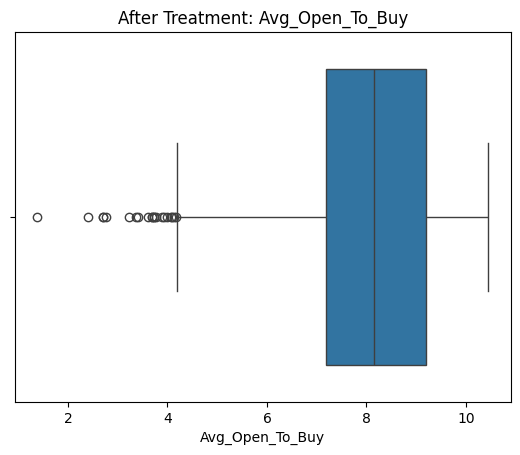

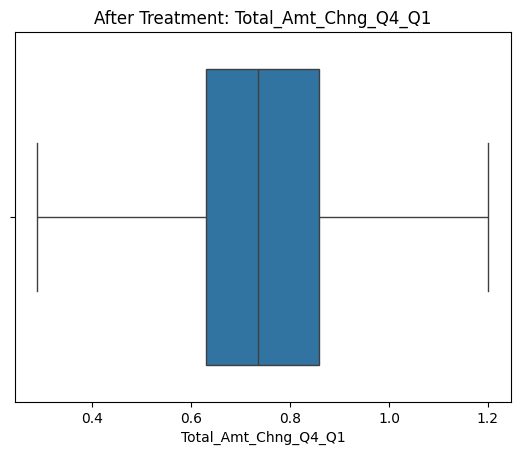

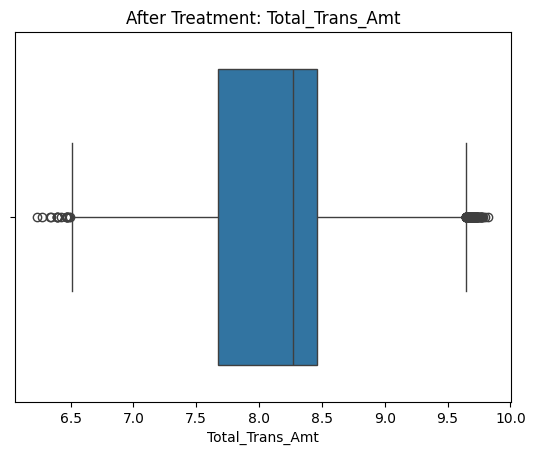

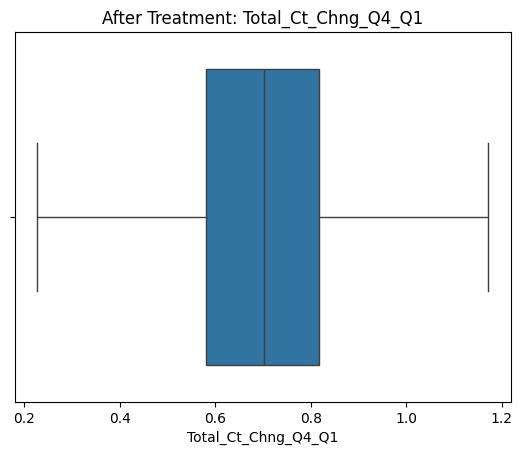

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    'Avg_Open_To_Buy',
    'Total_Amt_Chng_Q4_Q1',
    'Total_Trans_Amt',
    'Total_Ct_Chng_Q4_Q1'
]

for col in cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"After Treatment: {col}")
    plt.show()

After applying outlier treatment techniques, extreme values were significantly reduced. A small number of outliers were intentionally retained to preserve the natural variability and real-world behavior of the data.

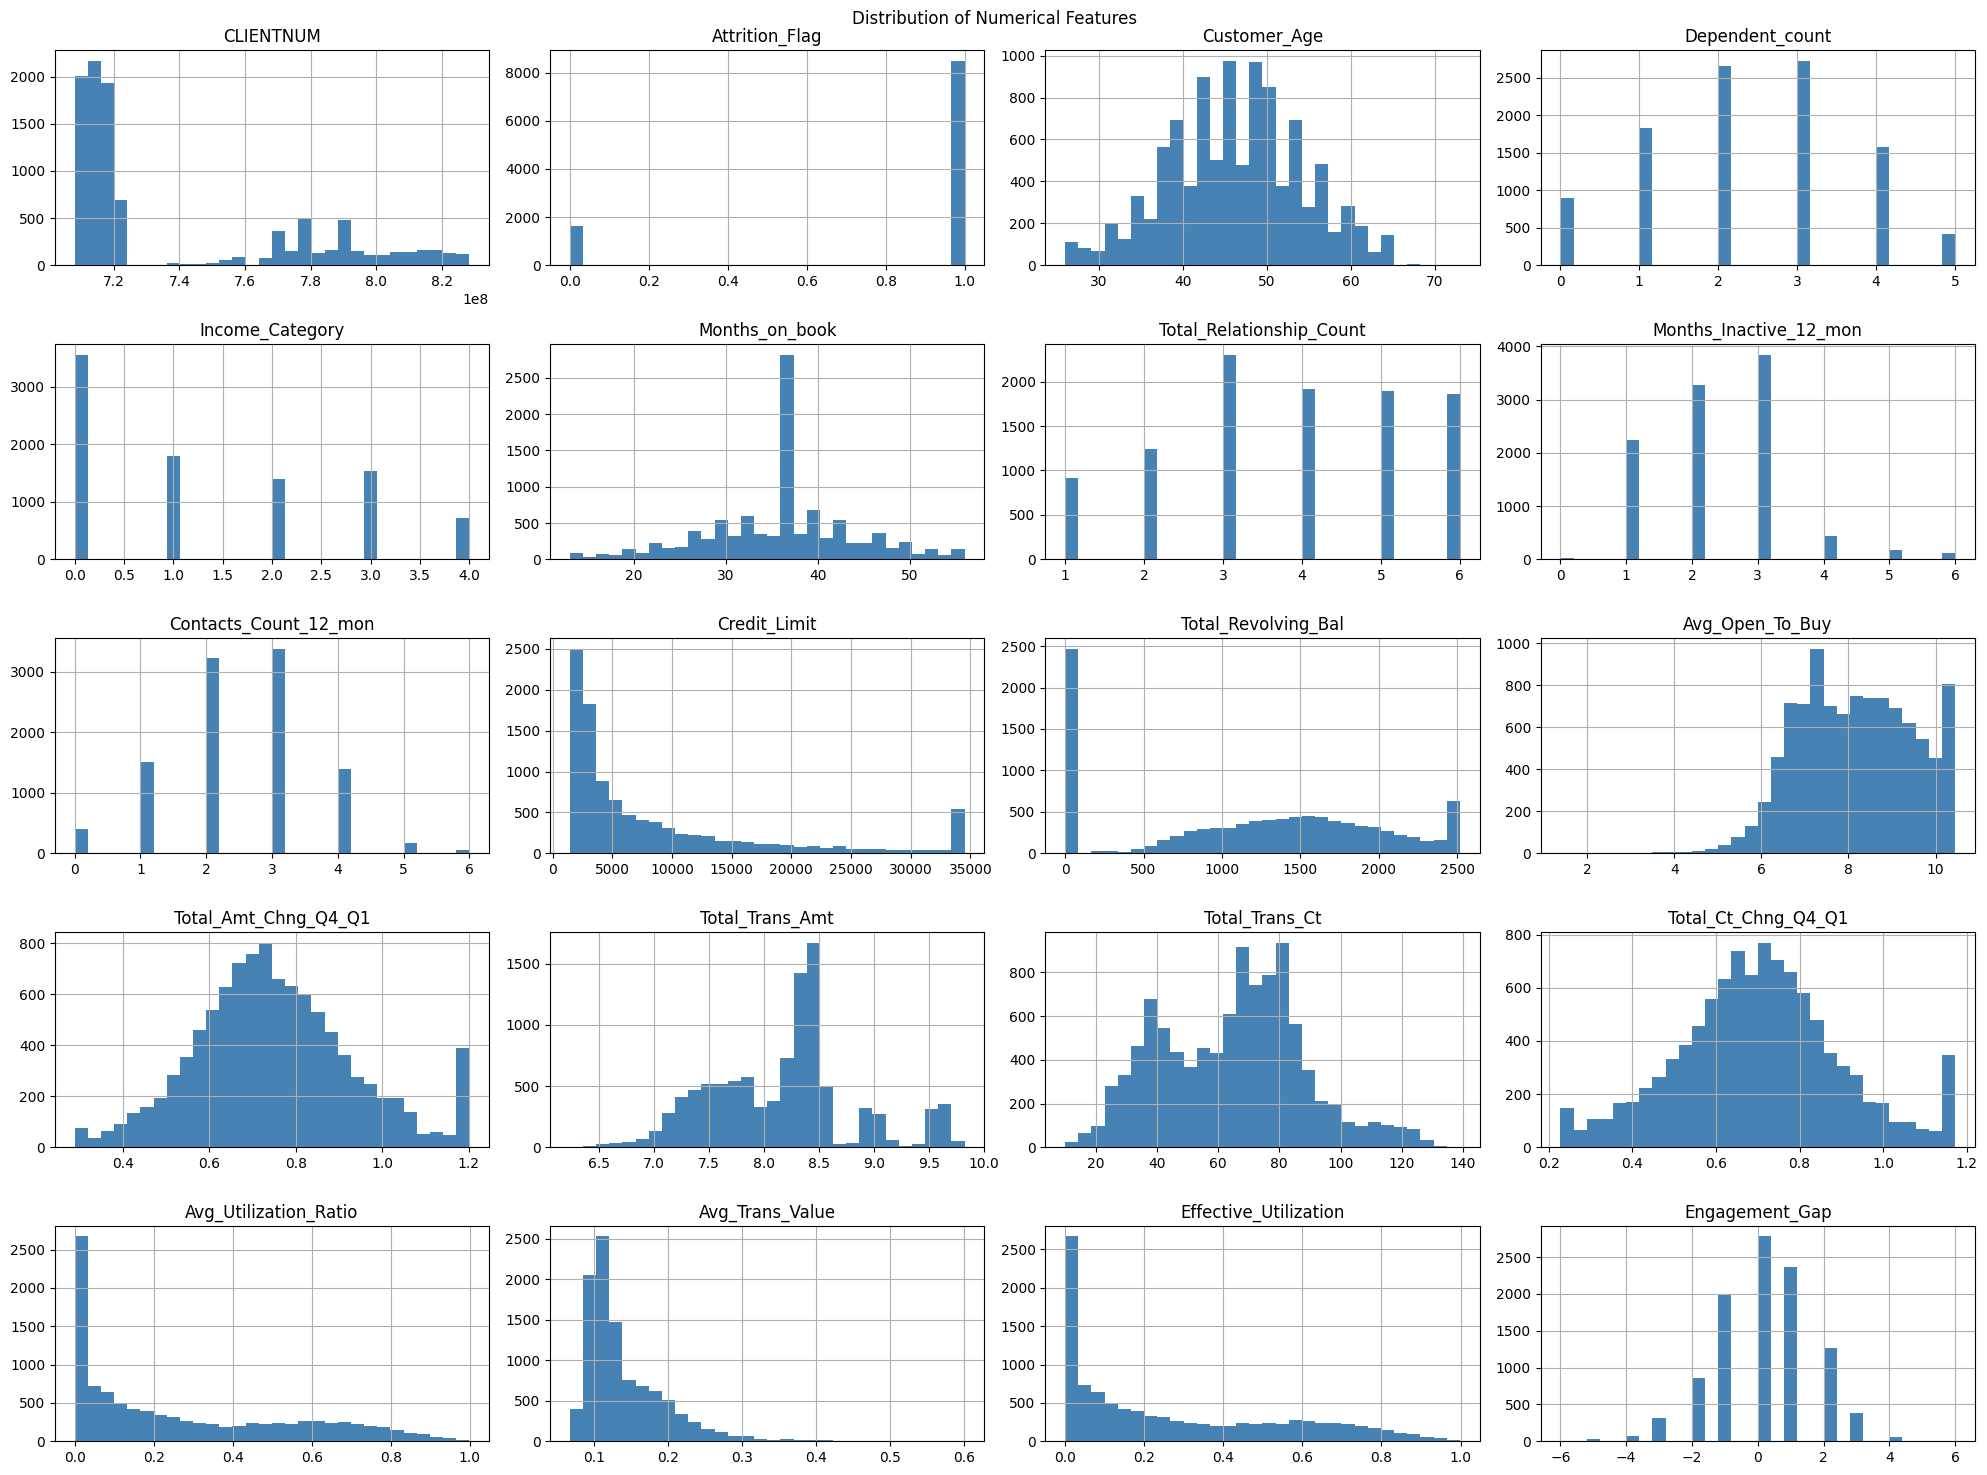

In [30]:
df.hist(figsize=(20,15), bins=30, color='steelblue')
plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

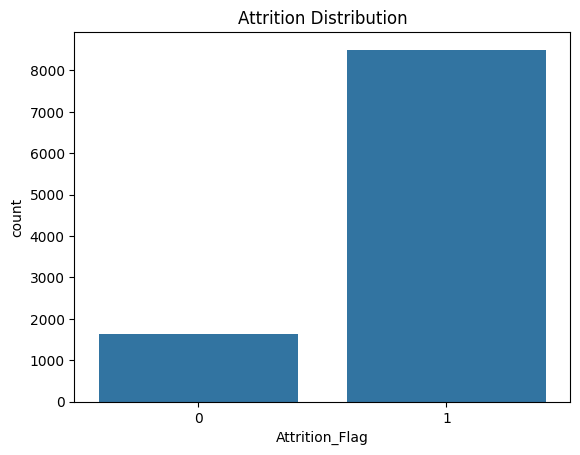

In [31]:
sns.countplot(x='Attrition_Flag', data=df)
plt.title("Attrition Distribution")
plt.show()

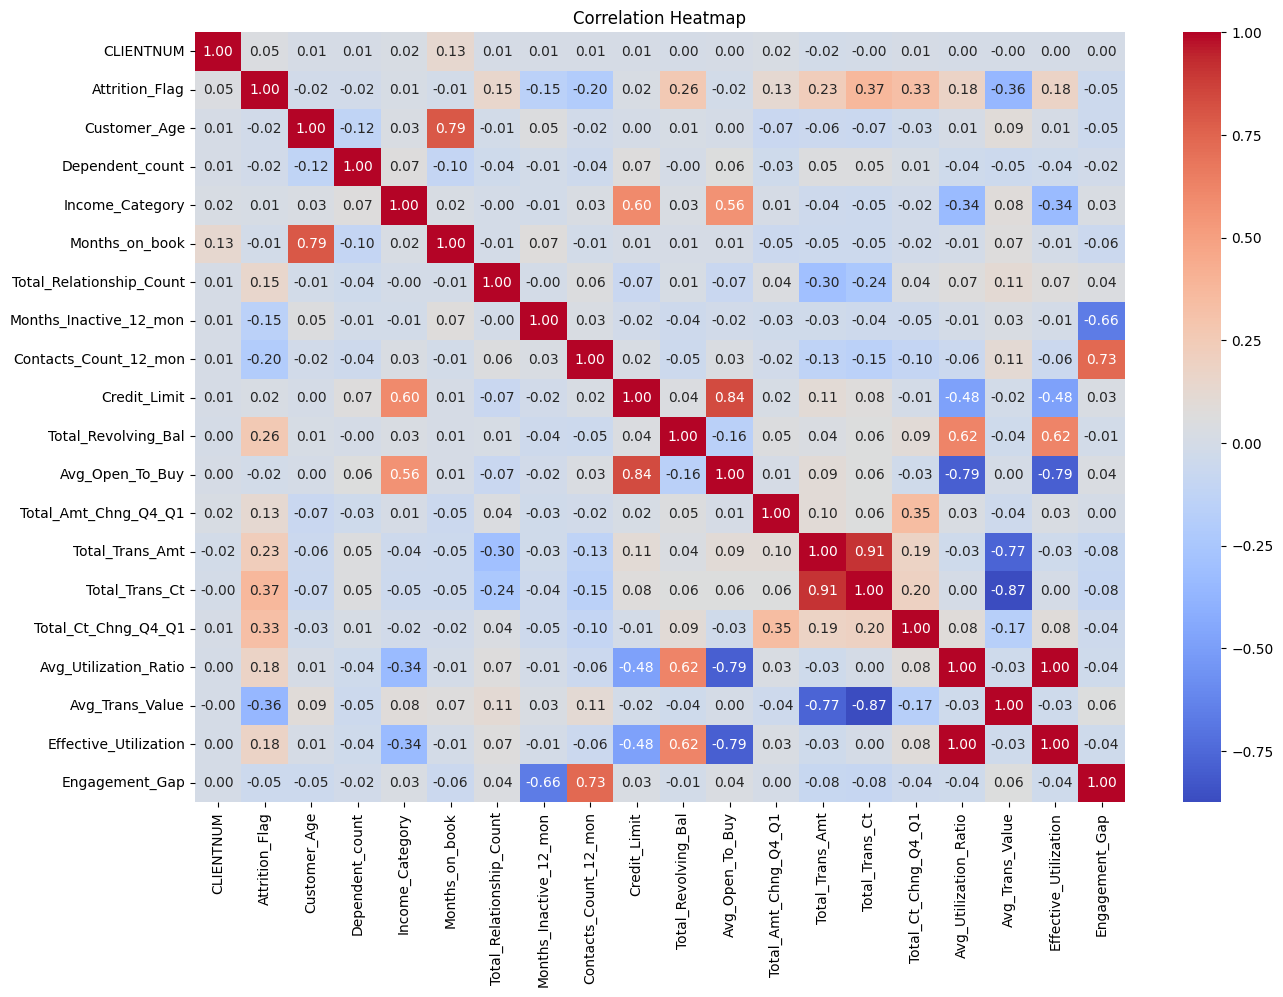

In [32]:
plt.figure(figsize=(15,10))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

 ENCODING

LABEL ENCODING

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Attrition_Flag'] = le.fit_transform(df['Attrition_Flag'])

ONE HOT ENCODING

In [16]:
columns_to_encode = [
    'Gender',
    'Marital_Status',
    'Education_Level',
    'Card_Category'
]
# Filter out columns that are no longer in the DataFrame
existing_columns_to_encode = [col for col in columns_to_encode if col in df.columns]

if existing_columns_to_encode:
    df = pd.get_dummies(df, columns=existing_columns_to_encode, drop_first=True)

ORDINAL ENCODING

In [17]:
income_map = {
    'Less than $40K': 0,
    '$40K - $60K': 1,
    '$60K - $80K': 2,
    '$80K - $120K': 3,
    '$120K +': 4
}

df['Income_Category'] = df['Income_Category'].map(income_map)

In [18]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Dependent_count,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,...,Marital_Status_Unknown,Education_Level_Doctorate,Education_Level_Graduate,Education_Level_High School,Education_Level_Post-Graduate,Education_Level_Uneducated,Education_Level_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,768805383,1,45,3,2.0,39,5,1,3,12691.0,...,False,False,False,True,False,False,False,False,False,False
1,818770008,1,49,5,0.0,44,6,1,2,8256.0,...,False,False,True,False,False,False,False,False,False,False
2,713982108,1,51,3,3.0,36,4,1,0,3418.0,...,False,False,True,False,False,False,False,False,False,False
3,769911858,1,40,4,0.0,34,3,4,1,3313.0,...,True,False,False,True,False,False,False,False,False,False
4,709106358,1,40,3,2.0,21,5,1,0,4716.0,...,False,False,False,False,False,True,False,False,False,False


Ordinal encoding was applied to Income_Category to preserve its inherent order, while one-hot encoding and label encoding were used for nominal and binary categorical variables respectively.

                                             FEATURE ENGINEERING

New features were engineered to better capture customer behavior, including credit usage efficiency, transaction patterns, engagement levels, and behavioral changes over time. These features improved the model’s ability to detect churn patterns.

In [19]:
df['Avg_Trans_Value'] = df['Total_Trans_Amt'] / (df['Total_Trans_Ct'] + 1)

ye btata he ke hr har transaction ka average amount
customer “big spender” hai ya “frequent small spender”

In [20]:
df['Effective_Utilization'] = df['Total_Revolving_Bal'] / (df['Credit_Limit'] + 1)

 ye btata he ke hr customer apna credit kitna use kar raha hai
high utilization = financially active / risky behavior

In [21]:
df['Engagement_Gap'] = df['Contacts_Count_12_mon'] - df['Months_Inactive_12_mon']

 ye btata he ke bank kitna contact kar raha vs customer kitna inactive hai
negative value = risky (inactive customer)

Three new features were engineered to capture customer spending behavior, credit utilization efficiency, and engagement level to improve churn prediction performance

In [22]:
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Dependent_count',
       'Income_Category', 'Months_on_book', 'Total_Relationship_Count',
       'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit',
       'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1',
       'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1',
       'Avg_Utilization_Ratio', 'Gender_M', 'Marital_Status_Married',
       'Marital_Status_Single', 'Marital_Status_Unknown',
       'Education_Level_Doctorate', 'Education_Level_Graduate',
       'Education_Level_High School', 'Education_Level_Post-Graduate',
       'Education_Level_Uneducated', 'Education_Level_Unknown',
       'Card_Category_Gold', 'Card_Category_Platinum', 'Card_Category_Silver',
       'Avg_Trans_Value', 'Effective_Utilization', 'Engagement_Gap'],
      dtype='object')

TRAIN TEST SPLIT

In [23]:
from sklearn.model_selection import train_test_split

# features (X) aur target (y)
X = df.drop('Attrition_Flag', axis=1)
y = df['Attrition_Flag']

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test data
    random_state=42,    # reproducibility
    stratify=y          # important for classification imbalance
)

In [24]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(8101, 32) (2026, 32)
Attrition_Flag
1    0.839279
0    0.160721
Name: proportion, dtype: float64
Attrition_Flag
1    0.839585
0    0.160415
Name: proportion, dtype: float64


 MODEL SELECTION

In [25]:
from sklearn.ensemble import RandomForestClassifier

In [26]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'   # imbalanced data ke liye important
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [27]:
y_pred = rf_model.predict(X_test)

In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9590325765054294

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.82      0.87       325
           1       0.97      0.99      0.98      1701

    accuracy                           0.96      2026
   macro avg       0.94      0.90      0.92      2026
weighted avg       0.96      0.96      0.96      2026


Confusion Matrix:

[[ 266   59]
 [  24 1677]]


In [35]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(
        class_weight='balanced',
        random_state=42),
    param_grid,
    n_iter=5,   # sirf 5
    cv=3,       # sirf 3 fold
    scoring='f1',
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)
print("Best Params:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Best Params: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 10}
Best Score: 0.9698439351352713


In [36]:
from sklearn.model_selection import cross_val_score

best_model = random_search.best_estimator_

cv_scores = cross_val_score(
    best_model, X_train, y_train,
    cv=5,
    scoring='f1'
)
print("CV Scores:", cv_scores)
print("Mean F1:", cv_scores.mean())
print("Std:", cv_scores.std())

CV Scores: [0.97136564 0.97142857 0.96617647 0.96938399 0.97460434]
Mean F1: 0.9705918029911802
Std: 0.0027696010698365255


In [37]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=200,
        min_samples_split=5,
        max_depth=10,
        class_weight='balanced',
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)
y_pred_pipe = pipeline.predict(X_test)
print("Pipeline Accuracy:",
      accuracy_score(y_test, y_pred_pipe))

Pipeline Accuracy: 0.9545903257650543


In [38]:
y_pred_tuned = pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

Accuracy: 0.9545903257650543

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       325
           1       0.98      0.97      0.97      1701

    accuracy                           0.95      2026
   macro avg       0.91      0.93      0.92      2026
weighted avg       0.96      0.95      0.96      2026


Confusion Matrix:
[[ 289   36]
 [  56 1645]]


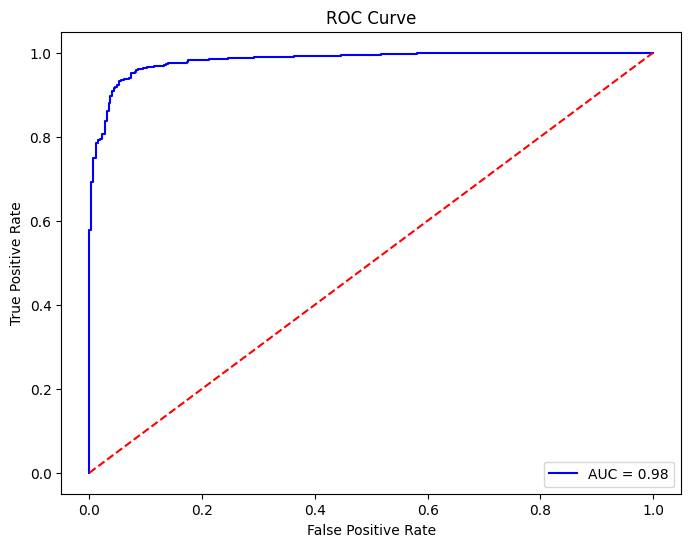

In [39]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test,
              pipeline.predict_proba(X_test)[:,1])
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr,
         label=f'AUC = {auc(fpr,tpr):.2f}',
         color='blue')
plt.plot([0,1],[0,1],'--', color='red')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

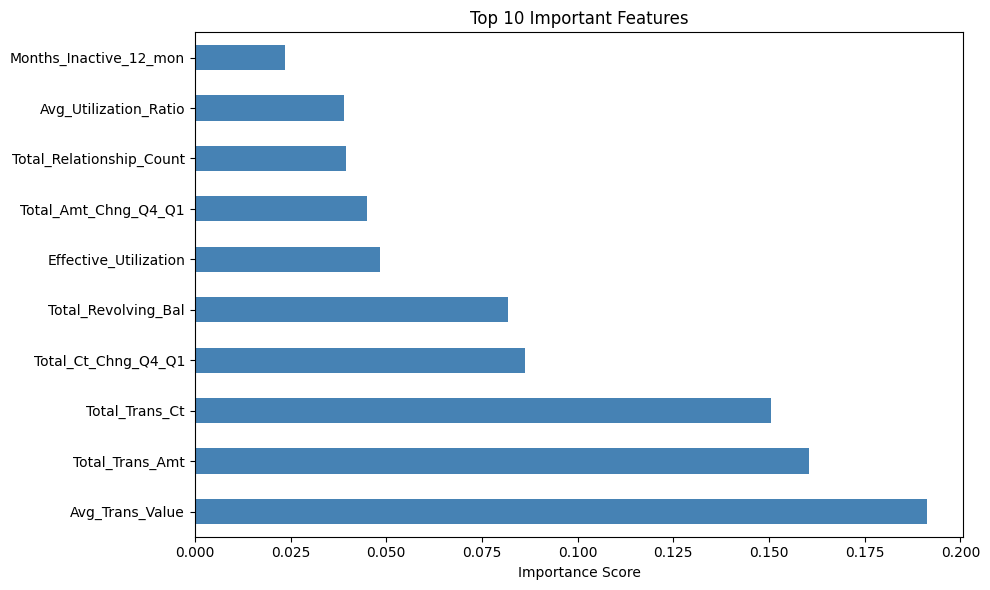

In [40]:
# Pipeline se model nikalo
rf = pipeline.named_steps['model']

feat_imp = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
)

plt.figure(figsize=(10,6))
feat_imp.nlargest(10).plot(
    kind='barh',
    color='steelblue'
)
plt.title("Top 10 Important Features")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

Conclusion

Project: Credit Card Customer Churn Prediction Using Random Forest

Overview:

This project was developed to predict customer churn in the banking sector using the BankChurners dataset. The dataset contained 10,127 customer records with 23 features including demographic, financial, and behavioral attributes. The target variable was Attrition_Flag which indicated whether a customer churned or not.

Data Exploration:

Initial exploration revealed that the dataset had no missing values and no duplicate records. The data contained both numerical and categorical features. The target variable was imbalanced with approximately 84% existing customers and 16% churned customers.

Data Cleaning:

Two columns named Naive_Bayes_Classifier_Attrition_Flag were removed from the dataset as they were not original input features. Including these columns would have caused data leakage and resulted in unrealistically high model performance.

Outlier Treatment:

Boxplots were used to detect outliers in numerical features. The following treatment was applied:

Log transformation was applied to Avg_Open_To_Buy and Total_Trans_Amt due to high skewness

IQR capping method was used for Total_Amt_Chng_Q4_Q1 and Total_Ct_Chng_Q4_Q1 to preserve natural data patterns

A small number of outliers were intentionally retained to preserve real-world variability

Encoding:

Three encoding techniques were applied based on the nature of each variable:

Label Encoding for Attrition_Flag (binary target variable)

One-Hot Encoding for Gender, Marital_Status, Education_Level and Card_Category (nominal variables)

Ordinal Encoding for Income_Category to preserve its natural order (Less than $40K to $120K+)

Feature Engineering:

Three new features were manually created to better capture customer behavior:

Avg_Trans_Value = Total_Trans_Amt / (Total_Trans_Ct + 1)

Identifies whether a customer is a big spender or frequent small spender

Effective_Utilization = Total_Revolving_Bal / (Credit_Limit + 1)

Measures how much of the credit limit a customer actually uses

Engagement_Gap = Contacts_Count_12_mon - Months_Inactive_12_mon

Captures the relationship between bank contacts and customer inactivity

Train Test Split:

The dataset was split into 80% training and 20% testing. Stratified splitting was used to maintain the same class ratio in both sets ensuring fair evaluation.

Model Selection:

Random Forest Classifier was selected as the primary model due to its ability to handle imbalanced data, high dimensionality and non-linear relationships. class_weight='balanced' was used to handle class imbalance effectively.

Model Performance Comparison:

Metric                          Before Tuning          After Tuning

Accuracy                          95.9%                  95.4%

Churn Recall                       82%                    89%

Churn Precision                     92%                  84%

Churn F1 Score                    0.87                  0.86

CV Mean F1                       -                     97.05%

AUC Score                          —                      0.98

Model Tuning:
  
RandomizedSearchCV was used with 5 iterations and 3-fold cross validation. The best parameters found were:

n_estimators: 200

max_depth: 10

min_samples_split: 5

Cross Validation:

5-fold cross validation was performed on the tuned model with the following results:

CV Scores: 97.13%, 97.14%, 96.61%, 96.93%, 97.46%

Mean F1 Score: 97.05%

Standard Deviation: 0.0027

The very low standard deviation confirms that the model is stable and
consistent across different data splits with no signs of overfitting.

Pipeline:

A full machine learning pipeline was built using StandardScaler and the tuned Random Forest model to ensure clean and reproducible predictions.

Final Evaluation:

Overall Accuracy: 95.4%

AUC Score: 0.98

The model correctly identified 289 out of 325 churned customers

Only 36 churners were missed

Feature Importance:
The top 10 most important features identified by the model were:

Rank     Feature

1        Avg_Trans_Value

2        Total_Trans_Amt

3        Total_Trans_Ct

4       Total_Ct_Chng_Q4_Q1

5       Total_Revolving_Bal

6      Effective_Utilization

7      Total_Amt_Chng_Q4_Q1

8      Total_Relationship_Count

9      Avg_Utilization_Ratio

10     Months_Inactive_12_mon

Notably Avg_Trans_Value which was manually engineered ranked as the most important feature proving that feature engineering significantly improved model performance.

Key Finding:

Customer transaction behavior is the strongest predictor of churn. Customers with lower transaction amounts and counts are significantly more likely to churn. Banks can use these insights to identify at-risk customers early and take proactive retention measures.

Overall Conclusion:

Despite a slight decrease in overall accuracy after tuning, the model showed a significant improvement in Churn Recall from 82% to 89%. This is more valuable in a banking context because missing a churner is far more costly than a false alarm. With an AUC score of 0.98 and CV Mean F1 of 97.05% this Random Forest model demonstrates excellent and reliable performance and is well suited for deployment in real banking systems to reduce customer attrition.

Model Performance on Test Data (2026 customers):

Total Customers Tested: 2026

Correctly Predicted:    1934

Wrongly Predicted:        92

Out of 325 actual churners:

- Model correctly caught 289 churners

- Model missed only 36 churners

Out of 1701 existing customers:

- Model correctly identified 1645

- Only 56 were wrongly flagged

Overall the model predicted 95.4% customers
correctly which is a very strong result.

AUC Score of 0.98 means the model can
almost perfectly distinguish between
churners and non-churners.

This model can help the bank to identify
at-risk customers early and take steps
to retain them before they leave.